# Ajuste fino de Kong para grabaciones caseras

Kong se entrenó con MAESTRO: grabaciones de concierto, limpias, y sin ninguna aumentación de datos (el `runme.sh` del repositorio original usa `--augmentation='none'`). En `amt-robustness.ipynb` el F1 de nota bajó de 83.8 % en audio limpio a 44.1 % en una grabación simulada de celular. El ruido y sobre todo la reverberación son lo que más lo afecta.

Este notebook reentrena la rama de notas con audio degradado al vuelo y compara el modelo antes y después, sobre las mismas veinte obras y las mismas condiciones de la evaluación de robustez.

El ajuste se considera útil si mejora al menos cinco puntos de F1 de nota en las condiciones degradadas y no pierde más de dos en MAESTRO limpio.

## 1. Instalación

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

pip("mir_eval")
pip("--no-deps", "piano_transcription_inference", "torchlibrosa")
pip("--no-deps", "pretty_midi", "mido")
pip("librosa", "soundfile", "audioread", "h5py")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.1 MB/s eta 0:00:00


## 2. Código original de entrenamiento

Se usa el repositorio de entrenamiento de Kong tal cual. De ahí salen la arquitectura de la rama de notas, el `TargetProcessor` que convierte el MIDI en los objetivos de regresión de onset y offset, y la función de pérdida. Así el ajuste optimiza exactamente lo mismo que el entrenamiento original y lo único que cambia es el audio de entrada.

Hay un solo cambio al código de Kong. Un dropout de la rama acústica usa `inplace=True`, algo que PyTorch 1.x toleraba y las versiones actuales rechazan en el backward. Pasarlo a `inplace=False` da el mismo resultado numérico.

In [2]:
from pathlib import Path

KONG = Path("/kaggle/working/piano_transcription")
if not KONG.exists():
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/bytedance/piano_transcription.git", str(KONG)], check=True)
models_py = KONG / "pytorch" / "models.py"
models_py.write_text(models_py.read_text().replace(
    "x = F.dropout(x, p=0.5, training=self.training, inplace=True)",
    "x = F.dropout(x, p=0.5, training=self.training, inplace=False)"))
sys.path[:0] = [str(KONG / "utils"), str(KONG / "pytorch")]

from utilities import TargetProcessor, read_midi
from models import Regress_onset_offset_frame_velocity_CRNN
from losses import regress_onset_offset_frame_velocity_bce
import config as kong_config

print(subprocess.run(["git", "-C", str(KONG), "rev-parse", "--short", "HEAD"],
                     capture_output=True, text=True).stdout.strip())

Cloning into '/kaggle/working/piano_transcription'...


1ade7dc


## 3. Configuración

| Parámetro | Valor | Por qué |
|---|---|---|
| Tasa de aprendizaje | 1e-4 | Cinco veces menor que la original (5e-4). Los pesos ya funcionan en MAESTRO y un paso grande los alejaría de ahí. |
| Decaimiento | ×0.9 cada 1000 iteraciones | El esquema original es ×0.9 cada 10 000 sobre 300 000 iteraciones. Se mantiene la forma, escalada a un entrenamiento mucho más corto. |
| Optimizador | Adam con AMSGrad | El mismo del original, para no cambiar dos cosas a la vez. |
| Lote | 8 segmentos | El original usó 12. Un lote de 8 no cabe completo en una T4, así que se reparte entre las dos GPUs de la máquina en pedazos de 4 y se suman los gradientes antes de actualizar. El resultado es el mismo que un lote de 8. |
| Segmento | 10 s | El mismo del original. El `TargetProcessor` está pensado para ese largo. |
| Iteraciones | hasta 6000 o 3.5 h | Lo que cabe en una sesión de Kaggle dejando tiempo para la evaluación. |
| Audio limpio | 30 % de los segmentos | Para que el modelo siga viendo cómo suena MAESTRO y no olvide lo que ya sabía. |
| Rama de pedal | congelada | El pedal no cambia con este ajuste. El pipeline lo sigue usando igual. |
| Obras | 150 de la partición `train`, primeros 4 min | Variedad de compositores sin cargar las 140 horas completas en memoria. |
| Validación | 12 obras de `validation` | Para elegir el mejor punto del entrenamiento sin mirar las obras de prueba. |

Las obras de prueba vienen de la partición `test` y ninguna aparece en entrenamiento ni en validación.

In [3]:
import json, glob, random, time
import numpy as np
import torch

SEED = 22779
SR = kong_config.sample_rate
SEGMENT_S = kong_config.segment_seconds
FPS = kong_config.frames_per_second

LEARNING_RATE = 1e-4
LR_DECAY = 0.9
LR_DECAY_EVERY = 1000
BATCH = 8
CHUNK = 4
MAX_ITERATIONS = 6000
MAX_TRAIN_HOURS = 3.5
CLEAN_RATIO = 0.3
VALIDATE_EVERY = 500

N_TRAIN_WORKS = 150
TRAIN_SECONDS = 240
N_VAL_WORKS = 12

N_TEST_WORKS = 20
FRAGMENT_S = 120
FRAGMENT_START_S = 30
ONSET_TOL = 0.05
OFFSET_RATIO = 0.2

DATASET_ROOT = None
for cand in glob.glob("/kaggle/input/*/"):
    hits = glob.glob(cand + "**/maestro-v3.0.0.csv", recursive=True)
    if hits:
        DATASET_ROOT = Path(hits[0]).parent
        break
assert DATASET_ROOT is not None, "Montar the-maestro-dataset-v3-0-0 como input"

OUT = Path("/kaggle/working")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
print(DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

cuda Tesla T4


## 4. Normalización de nivel

Un audio de celular puede llegar treinta o cuarenta decibeles más bajo que una grabación de concierto. El modelo trabaja sobre un log-mel, así que una diferencia de nivel se vuelve un desplazamiento constante de toda la entrada. Es la misma función que usa `src/amt/audio.py` en el pipeline: quita la componente continua y lleva el RMS de los tramos con sonido a un nivel de referencia, sin recortar picos.

El nivel de referencia se toma de MAESTRO mismo, para que el audio normalizado quede donde el modelo aprendió.

In [4]:
FRAME = 2048
ACTIVE_BELOW_PEAK_DB = 40.0
PEAK_CEILING = 0.99
SILENCE_DBFS = -80.0

def db(x):
    return 20.0 * np.log10(max(x, 1e-12))

def active_rms(x, frame=FRAME):
    n = len(x) // frame
    if n == 0:
        return float(np.sqrt(np.mean(x ** 2))) if len(x) else 0.0
    rms = np.sqrt(np.mean(x[: n * frame].reshape(n, frame) ** 2, axis=1))
    loud = rms[rms >= rms.max() * 10 ** (-ACTIVE_BELOW_PEAK_DB / 20)]
    return float(np.sqrt(np.mean(loud ** 2)))

def normalize_loudness(x, target_dbfs):
    x = np.asarray(x, dtype=np.float32)
    x = x - x.mean()
    level = active_rms(x)
    if db(level) < SILENCE_DBFS:
        return x
    gain = 10 ** ((target_dbfs - db(level)) / 20)
    peak = float(np.abs(x).max()) * gain
    if peak > PEAK_CEILING:
        gain *= PEAK_CEILING / peak
    return (x * gain).astype(np.float32)

## 5. Datos

Cada obra se carga una sola vez a 16 kHz y se guarda en memoria como `int16`. Los segmentos de 10 s se recortan al vuelo, así cada época ve cortes distintos de la misma obra.

In [5]:
import csv
import librosa
from joblib import Parallel, delayed

with open(DATASET_ROOT / "maestro-v3.0.0.csv", newline="", encoding="utf-8") as f:
    meta = list(csv.DictReader(f))

def resolve(rel):
    p = DATASET_ROOT / rel
    return p if p.exists() else Path(glob.glob(str(DATASET_ROOT / "**" / Path(rel).name), recursive=True)[0])

def load_work(w, offset, duration):
    audio, _ = librosa.load(str(resolve(w["audio_filename"])), sr=SR, mono=True,
                            offset=offset, duration=duration)
    midi = read_midi(str(resolve(w["midi_filename"])))
    return {"audio": (audio * 32767).astype(np.int16), "offset": offset,
            "events": midi["midi_event"], "times": midi["midi_event_time"],
            "name": Path(w["midi_filename"]).stem}

rng = random.Random(SEED)
train_meta = rng.sample([w for w in meta if w["split"] == "train"], N_TRAIN_WORKS)
val_meta = rng.sample([w for w in meta if w["split"] == "validation"], N_VAL_WORKS)

t0 = time.time()
train_works = Parallel(n_jobs=4)(delayed(load_work)(w, 0.0, TRAIN_SECONDS) for w in train_meta)
val_works = Parallel(n_jobs=4)(delayed(load_work)(w, 30.0, 25.0) for w in val_meta)
hours = sum(len(w["audio"]) for w in train_works) / SR / 3600
print(f"{len(train_works)} obras de entrenamiento, {hours:.1f} h de audio, {time.time() - t0:.0f} s")

levels = [db(active_rms(w["audio"].astype(np.float32) / 32767)) for w in train_works]
TARGET_DBFS = float(np.median(levels))
print(f"Nivel de referencia de MAESTRO: {TARGET_DBFS:.1f} dBFS "
      f"(p10 {np.percentile(levels, 10):.1f}, p90 {np.percentile(levels, 90):.1f})")

150 obras de entrenamiento, 9.6 h de audio, 84 s
Nivel de referencia de MAESTRO: -24.9 dBFS (p10 -32.3, p90 -20.7)


## 6. Degradaciones de entrenamiento

Son de la misma familia que las de la evaluación, pero con parámetros al azar en rangos amplios y con generadores distintos. Si el entrenamiento usara exactamente el ruido blanco a 20 dB y la reverberación de 0.6 s de la evaluación, la mejora medida sería en parte memorización de esas dos condiciones.

| Degradación | Probabilidad | Rango |
|---|---|---|
| Reverberación | 0.6 | RT60 entre 0.2 y 1.2 s, reflexiones tempranas al azar y cola filtrada |
| Ruido | 0.6 | SNR entre 5 y 35 dB, blanco, rosa o café |
| Micrófono de teléfono | 0.3 | Pasa altos entre 100 y 400 Hz, pasa bajos entre 3.5 y 8 kHz |
| MP3 | 0.4 | 32, 48, 64, 96 o 128 kbps |

Un segmento degradado recibe al menos una de estas. Al final todo pasa por la normalización de nivel, igual que en el pipeline.

In [6]:
from scipy.signal import fftconvolve, butter, sosfilt, lfilter

def colored_noise(n, color, rng):
    spec = np.fft.rfft(rng.standard_normal(n))
    f = np.maximum(np.fft.rfftfreq(n), 1.0 / n)
    spec *= {"blanco": 1.0, "rosa": f ** -0.5, "cafe": f ** -1.0}[color]
    noise = np.fft.irfft(spec, n)
    return noise / (np.std(noise) + 1e-9)

def room_ir(rng):
    rt60 = rng.uniform(0.2, 1.2)
    t = np.arange(int(rt60 * SR)) / SR
    tail = rng.standard_normal(len(t)) * np.exp(-6.9 * t / rt60)
    damping = rng.uniform(0.1, 0.7)
    tail = lfilter([1 - damping], [1, -damping], tail)
    ir = tail * 10 ** (rng.uniform(-12, 0) / 20) / (np.abs(tail).max() + 1e-9)
    for _ in range(rng.integers(3, 12)):
        ir[rng.integers(int(0.002 * SR), int(0.05 * SR))] += rng.uniform(0.2, 0.7) * rng.choice([-1, 1])
    ir[0] = 1.0
    return ir

def mp3(x, bitrate):
    import os
    import soundfile as sf
    src, dst = f"/tmp/_{os.getpid()}.wav", f"/tmp/_{os.getpid()}.mp3"
    sf.write(src, x, SR)
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", src, "-b:a", bitrate, dst], check=True)
    y, _ = librosa.load(dst, sr=SR, mono=True)
    return np.pad(y, (0, max(0, len(x) - len(y))))[: len(x)]

def degrade_train(x, rng):
    ops = {"reverb": rng.random() < 0.6, "ruido": rng.random() < 0.6,
           "telefono": rng.random() < 0.3, "mp3": rng.random() < 0.4}
    if not any(ops.values()):
        ops[rng.choice(list(ops))] = True
    peak = np.abs(x).max() + 1e-9
    if ops["reverb"]:
        x = fftconvolve(x, room_ir(rng))[: len(x)]
        x = x / (np.abs(x).max() + 1e-9) * peak
    if ops["telefono"]:
        sos = butter(4, [rng.uniform(100, 400), rng.uniform(3500, 7900)], btype="band", fs=SR, output="sos")
        x = sosfilt(sos, x)
    if ops["ruido"]:
        noise = colored_noise(len(x), rng.choice(["blanco", "rosa", "cafe"]), rng)
        x = x + noise * np.sqrt(np.mean(x ** 2) / 10 ** (rng.uniform(5, 35) / 10))
    if ops["mp3"]:
        x = mp3(x, f"{rng.choice([32, 48, 64, 96, 128])}k")
    return x.astype(np.float32)

## 7. Segmentos y objetivos

Cada índice del dataset fija con su propia semilla la obra, el punto de inicio y las degradaciones. Una corrida repetida ve exactamente los mismos segmentos.

In [7]:
from torch.utils.data import Dataset, DataLoader

target_processor = TargetProcessor(segment_seconds=SEGMENT_S, frames_per_second=FPS,
                                   begin_note=kong_config.begin_note,
                                   classes_num=kong_config.classes_num)
SEG = int(SEGMENT_S * SR)
TARGET_KEYS = ["reg_onset_roll", "reg_offset_roll", "frame_roll", "velocity_roll", "onset_roll", "mask_roll"]

def make_example(work, start_sample, degrade, rng):
    x = work["audio"][start_sample: start_sample + SEG].astype(np.float32) / 32767
    x = np.pad(x, (0, SEG - len(x)))
    if degrade:
        x = degrade_train(x, rng)
    x = normalize_loudness(x, TARGET_DBFS)
    start_time = work["offset"] + start_sample / SR
    targets, _, _ = target_processor.process(start_time, work["times"], work["events"], extend_pedal=True)
    return {"waveform": x, **{k: targets[k].astype(np.float32) for k in TARGET_KEYS}}

class TrainSegments(Dataset):
    def __len__(self):
        return MAX_ITERATIONS * BATCH

    def __getitem__(self, idx):
        rng = np.random.default_rng([SEED, idx])
        work = train_works[rng.integers(len(train_works))]
        start = int(rng.integers(0, max(1, len(work["audio"]) - SEG)))
        return make_example(work, start, rng.random() >= CLEAN_RATIO, rng)

def collate(items):
    return {k: torch.from_numpy(np.stack([it[k] for it in items])) for k in items[0]}

train_loader = DataLoader(TrainSegments(), batch_size=BATCH, shuffle=False, num_workers=4,
                          collate_fn=collate, persistent_workers=True, prefetch_factor=4)

val_items = []
for i, w in enumerate(val_works):
    for k, start in enumerate((0, 10 * SR)):
        rng = np.random.default_rng([SEED, 10 ** 6, i, k])
        val_items.append(("limpio", make_example(w, start, False, rng)))
        val_items.append(("degradado", make_example(w, start, True, rng)))
print(f"{len(val_items)} segmentos de validación")

48 segmentos de validación


## 8. Modelo

Se parte del checkpoint publicado, el mismo que usa el pipeline. Solo se entrena la rama de notas.

In [8]:
from piano_transcription_inference import PianoTranscription

PianoTranscription(device="cpu")
BASE_CKPT = str(Path.home() / "piano_transcription_inference_data" / "note_F1=0.9677_pedal_F1=0.9186.pth")
base = torch.load(BASE_CKPT, map_location="cpu")

model = Regress_onset_offset_frame_velocity_CRNN(frames_per_second=FPS, classes_num=kong_config.classes_num)
model.load_state_dict(base["model"]["note_model"], strict=True)
model.to(DEVICE)
N_GPUS = torch.cuda.device_count()
net = model
if N_GPUS > 1:
    model = torch.nn.DataParallel(model)
    CHUNK *= N_GPUS

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999),
                             eps=1e-8, weight_decay=0.0, amsgrad=True)
print(f"{sum(p.numel() for p in net.parameters()):,} parámetros en la rama de notas, {N_GPUS} GPU")

Checkpoint path: /root/piano_transcription_inference_data/note_F1=0.9677_pedal_F1=0.9186.pth
Total size: ~165 MB


--2026-09-26 17:39:20--  https://zenodo.org/record/4034264/files/CRNN_note_F1%3D0.9677_pedal_F1%3D0.9186.pth?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4034264/files/CRNN_note_F1=0.9677_pedal_F1=0.9186.pth [following]
--2026-09-26 17:39:20--  https://zenodo.org/records/4034264/files/CRNN_note_F1=0.9677_pedal_F1=0.9186.pth
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 171966578 (164M) [application/octet-stream]
Saving to: ‘/root/piano_transcription_inference_data/note_F1=0.9677_pedal_F1=0.9186.pth’

     0K .......... .......... .......... .......... ..........  0%  229K 12m14s
    50K .......... .......... .......... .......... ..........  0%  462K 9m9s
   100K .......... .......... .......... .......... ..........  0% 6.84

Using cpu for inference.
Using CPU.
24,651,903 parámetros en la rama de notas, 2 GPU


## 9. Validación

In [9]:
@torch.no_grad()
def validate():
    model.eval()
    losses = {"limpio": [], "degradado": []}
    for i in range(0, len(val_items), CHUNK):
        chunk = val_items[i: i + CHUNK]
        batch = {k: v.to(DEVICE) for k, v in collate([it for _, it in chunk]).items()}
        out = model(batch["waveform"])
        for j, (kind, _) in enumerate(chunk):
            single = {k: v[j: j + 1] for k, v in out.items()}
            target = {k: v[j: j + 1] for k, v in batch.items()}
            losses[kind].append(float(regress_onset_offset_frame_velocity_bce(model, single, target)))
    model.train()
    return {k: float(np.mean(v)) for k, v in losses.items()}

history = [{"iteration": 0, **validate()}]
print(history[-1])

{'iteration': 0, 'limpio': 0.6963465089599291, 'degradado': 0.7597820187608401}


## 10. Entrenamiento

Cada 500 iteraciones se valida. Se guarda el punto con menor pérdida promedio entre audio limpio y degradado, no el último. Así un sobreajuste al final del entrenamiento no se cuela en el modelo que se evalúa.

In [10]:
import copy

best = {"loss": np.mean([history[0]["limpio"], history[0]["degradado"]]), "iteration": 0,
        "state": copy.deepcopy(net.state_dict())}
model.train()
t0 = time.time()
running = []

for iteration, batch in enumerate(train_loader, start=1):
    batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
    optimizer.zero_grad(set_to_none=True)
    total = 0.0
    for i in range(0, BATCH, CHUNK):
        part = {k: v[i: i + CHUNK] for k, v in batch.items()}
        loss = regress_onset_offset_frame_velocity_bce(model, model(part["waveform"]), part)
        (loss * len(part["waveform"]) / BATCH).backward()
        total += float(loss) * len(part["waveform"]) / BATCH
    optimizer.step()
    running.append(total)

    if iteration % LR_DECAY_EVERY == 0:
        for g in optimizer.param_groups:
            g["lr"] *= LR_DECAY

    if iteration % 100 == 0:
        print(f"{iteration:5d}  pérdida {np.mean(running):.4f}  lr {optimizer.param_groups[0]['lr']:.2e}  "
              f"{(time.time() - t0) / 60:5.1f} min")
        running = []

    out_of_time = (time.time() - t0) / 3600 > MAX_TRAIN_HOURS
    if iteration % VALIDATE_EVERY == 0 or out_of_time or iteration == MAX_ITERATIONS:
        v = validate()
        history.append({"iteration": iteration, **v})
        mean = np.mean([v["limpio"], v["degradado"]])
        if mean < best["loss"]:
            best = {"loss": mean, "iteration": iteration, "state": copy.deepcopy(net.state_dict())}
        print(f"      validación  limpio {v['limpio']:.4f}  degradado {v['degradado']:.4f}  "
              f"mejor en {best['iteration']}")
    if out_of_time:
        print("Se alcanzó el límite de tiempo")
        break

(OUT / "historial_ajuste.json").write_text(json.dumps(history, indent=1))
print(f"Mejor punto: iteración {best['iteration']}")

/tmp/ipykernel_23/2733242866.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total += float(loss) * len(part["waveform"]) / BATCH


  100  pérdida 0.7263  lr 1.00e-04    3.4 min
  200  pérdida 0.7199  lr 1.00e-04    6.7 min
  300  pérdida 0.7223  lr 1.00e-04    9.9 min
  400  pérdida 0.7247  lr 1.00e-04   13.2 min
  500  pérdida 0.7200  lr 1.00e-04   16.5 min
      validación  limpio 0.7009  degradado 0.7195  mejor en 500
  600  pérdida 0.7160  lr 1.00e-04   19.8 min
  700  pérdida 0.7165  lr 1.00e-04   23.0 min
  800  pérdida 0.7139  lr 1.00e-04   26.2 min
  900  pérdida 0.7173  lr 1.00e-04   29.4 min
 1000  pérdida 0.7175  lr 9.00e-05   32.6 min
      validación  limpio 0.7004  degradado 0.7176  mejor en 1000
 1100  pérdida 0.7143  lr 9.00e-05   35.9 min
 1200  pérdida 0.7157  lr 9.00e-05   39.0 min
 1300  pérdida 0.7115  lr 9.00e-05   42.2 min
 1400  pérdida 0.7143  lr 9.00e-05   45.3 min
 1500  pérdida 0.7143  lr 9.00e-05   48.5 min
      validación  limpio 0.6994  degradado 0.7150  mejor en 1500
 1600  pérdida 0.7159  lr 9.00e-05   51.7 min
 1700  pérdida 0.7135  lr 9.00e-05   54.9 min
 1800  pérdida 0.7120  l

## 11. Checkpoint

Se guarda con el mismo formato del checkpoint original, con la rama de pedal intacta, para que `AMTTranscriber(checkpoint_path=...)` lo use sin cambios. El paquete de inferencia carga con `strict=False` y reemplaza por el original cualquier archivo menor a 160 MB, así que aquí se comprueban las dos cosas.

In [11]:
FT_CKPT = OUT / "kong_ajustado.pth"
tuned = copy.deepcopy(base)
tuned["model"]["note_model"] = {k: v.detach().cpu() for k, v in best["state"].items()}
tuned["ajuste"] = {"iteracion": best["iteration"], "nivel_referencia_dbfs": TARGET_DBFS, "semilla": SEED}
torch.save(tuned, FT_CKPT)
size = FT_CKPT.stat().st_size
assert size >= 1.6e8, f"El checkpoint pesa {size / 1e6:.0f} MB y el paquete lo reemplazaría"

check = PianoTranscription(device="cpu", checkpoint_path=str(FT_CKPT))
loaded = check.model.note_model.state_dict()
assert all(torch.equal(loaded[k].cpu(), v) for k, v in tuned["model"]["note_model"].items())
print(f"{FT_CKPT.name}: {size / 1e6:.0f} MB, pesos verificados")
del check

Checkpoint path: /kaggle/working/kong_ajustado.pth
Using cpu for inference.
Using CPU.
kong_ajustado.pth: 172 MB, pesos verificados


## 12. Evaluación

Mismas veinte obras, mismos fragmentos y mismas degradaciones que en `amt-robustness.ipynb`. Se agrega una condición `bajo`, el audio limpio treinta decibeles más bajo, para ver qué aporta la normalización por sí sola.

Se comparan tres variantes:

| Variante | Modelo | Normalización |
|---|---|---|
| `original` | Checkpoint publicado | No |
| `original_norm` | Checkpoint publicado | Sí |
| `ajustado` | Checkpoint de este notebook | Sí |

In [12]:
import pretty_midi
import mir_eval.transcription as mt
import soundfile as sf

def pedal_intervals(pm):
    ccs = sorted((cc for inst in pm.instruments for cc in inst.control_changes if cc.number == 64),
                 key=lambda c: c.time)
    out, down = [], None
    for cc in ccs:
        if cc.value >= 64 and down is None:
            down = cc.time
        elif cc.value < 64 and down is not None:
            out.append((down, cc.time))
            down = None
    if down is not None:
        out.append((down, float("inf")))
    return out

def extend_with_pedal(notes, pedal):
    next_onset, by_pitch = {}, {}
    for n in notes:
        by_pitch.setdefault(n.pitch, []).append(n)
    for group in by_pitch.values():
        group.sort(key=lambda n: n.start)
        for a, b in zip(group, group[1:]):
            next_onset[id(a)] = b.start
    out = []
    for n in notes:
        end = n.end
        for s, r in pedal:
            if s <= end < r:
                end = r
                break
        end = min(end, next_onset.get(id(n), float("inf")))
        out.append((n.start, max(end, n.start + 1e-6), n.pitch))
    return out

def load_reference(midi_path, start, duration):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    notes = [n for inst in pm.instruments if not inst.is_drum for n in inst.notes]
    notes = extend_with_pedal(notes, pedal_intervals(pm))
    end = start + duration
    notes = sorted((s - start, min(e, end) - start, p) for s, e, p in notes if start <= s < end)
    return (np.array([[s, e] for s, e, _ in notes]),
            np.array([pretty_midi.note_number_to_hz(p) for _, _, p in notes]))

def evaluate(ref_i, ref_p, est_i, est_p):
    if len(est_i) == 0:
        return {"f1_onset": 0.0, "f1_note": 0.0, "ner": 1.0}
    _, _, f_on, _ = mt.precision_recall_f1_overlap(ref_i, ref_p, est_i, est_p,
                                                   onset_tolerance=ONSET_TOL, offset_ratio=None)
    _, _, f_note, _ = mt.precision_recall_f1_overlap(ref_i, ref_p, est_i, est_p, onset_tolerance=ONSET_TOL,
                                                     offset_ratio=OFFSET_RATIO, offset_min_tolerance=0.05)
    tp = len(mt.match_notes(ref_i, ref_p, est_i, est_p, onset_tolerance=ONSET_TOL, offset_ratio=None))
    return {"f1_onset": float(f_on), "f1_note": float(f_note),
            "ner": float((len(ref_i) - tp + len(est_i) - tp) / len(ref_i))}

eval_rng = np.random.default_rng(SEED)

def add_noise(x, snr_db=20):
    noise = eval_rng.standard_normal(len(x))
    return x + noise * np.sqrt(np.mean(x ** 2) / (10 ** (snr_db / 10) * np.mean(noise ** 2)))

def add_reverb(x, rt60=0.6):
    t = np.arange(int(rt60 * SR)) / SR
    ir = eval_rng.standard_normal(len(t)) * np.exp(-6.9 * t / rt60)
    ir[0] = 1.0
    y = fftconvolve(x, ir)[: len(x)]
    return y / (np.max(np.abs(y)) + 1e-9) * np.max(np.abs(x))

CONDITIONS = {
    "limpio": lambda x: x,
    "mp3": lambda x: mp3(x, "64k"),
    "ruido": add_noise,
    "reverb": add_reverb,
    "celular": lambda x: mp3(add_noise(add_reverb(x)), "64k"),
    "bajo": lambda x: x * 10 ** (-30 / 20),
}

test_meta = random.Random(SEED).sample([w for w in meta if w["split"] == "test"], N_TEST_WORKS)
cases = []
for w in test_meta:
    audio, _ = librosa.load(str(resolve(w["audio_filename"])), sr=SR, mono=True,
                            offset=FRAGMENT_START_S, duration=FRAGMENT_S)
    ref = load_reference(resolve(w["midi_filename"]), FRAGMENT_START_S, FRAGMENT_S)
    for cond, fn in CONDITIONS.items():
        cases.append({"work": Path(w["midi_filename"]).stem, "condition": cond,
                      "audio": fn(audio).astype(np.float32), "ref": ref})
print(f"{len(cases)} casos de prueba")

120 casos de prueba


In [13]:
RESULTS = OUT / "evaluacion_ajuste"
RESULTS.mkdir(exist_ok=True)

VARIANTS = {
    "original": (BASE_CKPT, False),
    "original_norm": (BASE_CKPT, True),
    "ajustado": (str(FT_CKPT), True),
}

for variant, (ckpt, normalize) in VARIANTS.items():
    transcriber = PianoTranscription(device=DEVICE, checkpoint_path=ckpt)
    for case in cases:
        out = RESULTS / f"{variant}__{case['condition']}__{case['work']}.json"
        if out.exists():
            continue
        x = normalize_loudness(case["audio"], TARGET_DBFS) if normalize else case["audio"]
        events = transcriber.transcribe(x, None)["est_note_events"]
        est = [(float(e["onset_time"]), float(e["offset_time"]), int(e["midi_note"])) for e in events]
        est_i = np.array([[s, e] for s, e, _ in est]) if est else np.zeros((0, 2))
        est_p = np.array([pretty_midi.note_number_to_hz(p) for _, _, p in est]) if est else np.zeros(0)
        m = evaluate(*case["ref"], est_i, est_p)
        m.update({"variant": variant, "condition": case["condition"], "work": case["work"], "est_notes": est})
        out.write_text(json.dumps(m))
    print(f"{variant} listo")
    del transcriber
    torch.cuda.empty_cache()

Checkpoint path: /root/piano_transcription_inference_data/note_F1=0.9677_pedal_F1=0.9186.pth
Using cuda for inference.
GPU number: 2
Segment 0 / 23
Segment 1 / 23
Segment 2 / 23
Segment 3 / 23
Segment 4 / 23
Segment 5 / 23
Segment 6 / 23
Segment 7 / 23
Segment 8 / 23
Segment 9 / 23
Segment 10 / 23
Segment 11 / 23
Segment 12 / 23
Segment 13 / 23
Segment 14 / 23
Segment 15 / 23
Segment 16 / 23
Segment 17 / 23
Segment 18 / 23
Segment 19 / 23
Segment 20 / 23
Segment 21 / 23
Segment 22 / 23
Segment 23 / 23
Segment 0 / 23
Segment 1 / 23
Segment 2 / 23
Segment 3 / 23
Segment 4 / 23
Segment 5 / 23
Segment 6 / 23
Segment 7 / 23
Segment 8 / 23
Segment 9 / 23
Segment 10 / 23
Segment 11 / 23
Segment 12 / 23
Segment 13 / 23
Segment 14 / 23
Segment 15 / 23
Segment 16 / 23
Segment 17 / 23
Segment 18 / 23
Segment 19 / 23
Segment 20 / 23
Segment 21 / 23
Segment 22 / 23
Segment 23 / 23
Segment 0 / 23
Segment 1 / 23
Segment 2 / 23
Segment 3 / 23
Segment 4 / 23
Segment 5 / 23
Segment 6 / 23
Segment 7 / 23

## 13. Resultados

In [14]:
import pandas as pd

df = pd.DataFrame([json.loads(p.read_text()) for p in RESULTS.glob("*.json")]).drop(columns="est_notes")
order = list(CONDITIONS)

f1_note = (df.pivot_table(index="condition", columns="variant", values="f1_note", aggfunc="mean")
             .mul(100).round(2).reindex(order)[list(VARIANTS)])
f1_note["mejora"] = (f1_note["ajustado"] - f1_note["original"]).round(2)
f1_note

variant,original,original_norm,ajustado,mejora
condition,,,,
limpio,83.81,83.77,81.69,-2.12
mp3,82.21,82.23,81.53,-0.68
ruido,75.24,75.09,76.48,1.24
reverb,62.58,62.57,68.15,5.57
celular,44.14,43.92,59.73,15.59
bajo,54.40,83.77,81.69,27.29


In [15]:
resumen = (df.groupby(["variant", "condition"])[["f1_onset", "f1_note", "ner"]].mean()
             .mul(100).round(2))
resumen.to_csv(OUT / "resumen_ajuste.csv")

degradadas = ["mp3", "ruido", "reverb", "celular"]
mejora = f1_note.loc[degradadas, "mejora"].mean()
perdida_limpio = f1_note.loc["limpio", "ajustado"] - f1_note.loc["limpio", "original"]

print(f"Mejora promedio en condiciones degradadas: {mejora:+.2f} puntos")
print(f"Cambio en MAESTRO limpio: {perdida_limpio:+.2f} puntos")
print(f"Efecto de la normalización con audio bajo: "
      f"{f1_note.loc['bajo', 'original_norm'] - f1_note.loc['bajo', 'original']:+.2f} puntos")
print()
print("El ajuste mejora lo suficiente" if mejora >= 5 else "La mejora queda por debajo de 5 puntos")
print("y conserva MAESTRO limpio" if perdida_limpio >= -2 else "pero pierde más de 2 puntos en limpio")

Mejora promedio en condiciones degradadas: +5.43 puntos
Cambio en MAESTRO limpio: -2.12 puntos
Efecto de la normalización con audio bajo: +29.37 puntos

El ajuste mejora lo suficiente
pero pierde más de 2 puntos en limpio


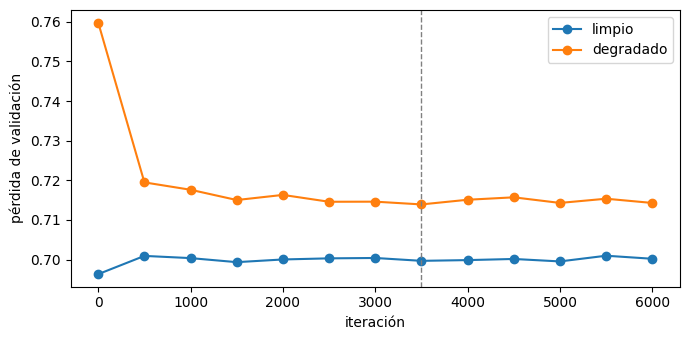

In [16]:
import matplotlib.pyplot as plt

h = pd.DataFrame(history)
plt.figure(figsize=(7, 3.5))
plt.plot(h["iteration"], h["limpio"], marker="o", label="limpio")
plt.plot(h["iteration"], h["degradado"], marker="o", label="degradado")
plt.axvline(best["iteration"], color="gray", linestyle="--", linewidth=1)
plt.xlabel("iteración")
plt.ylabel("pérdida de validación")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "curva_validacion.png", dpi=120)
plt.show()

### Observaciones

- El ajuste ayuda sobre todo con reverberación: +5.6 puntos con reverb sola y +15.6 en la grabación simulada de celular, que pasa de 44.1 % a 59.7 %. Con ruido solo la mejora es de 1.2 puntos y con MP3 el modelo pierde 0.7.
- El promedio de las cuatro condiciones degradadas sube 5.4 puntos.
- En MAESTRO limpio el F1 de nota baja de 83.8 % a 81.7 %, una pérdida de 2.1 puntos. Queda apenas por encima del margen de dos puntos fijado al inicio.
- La normalización no cambia nada con audio a nivel normal (83.8 % en ambos casos). Con el audio treinta decibeles más bajo el modelo original cae a 54.4 % y con normalización vuelve a 83.8 %.
- La pérdida de validación con audio degradado baja de 0.760 a 0.714 y se estanca desde la iteración 3500, que es el punto guardado. La de audio limpio casi no se mueve.
- La caída en limpio probablemente viene de las capas de BatchNorm. Sus estadísticas se recalculan durante el ajuste con una mezcla donde el 70 % del audio está degradado, así que el modelo termina normalizando el audio limpio como si tuviera ruido y eco.